<a href="https://colab.research.google.com/github/EvenSol/NeqSim-Colab/blob/master/notebooks/process/LNG_Liquefaction_Processes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# LNG liquefaction processes with NeqSim

This tutorial develops a reproducible thermodynamic screening model for natural-gas
liquefaction, high-pressure cooling, Joule--Thomson letdown, flash-gas separation, and
three common refrigeration architectures.

**Intended audience.** Process, mechanical, and energy engineers who know basic mass and
energy balances and want to understand how NeqSim connects a fluid model to process units.

**Prerequisites.** Python fundamentals; temperature, pressure, enthalpy, and phase-equilibrium
concepts. All inputs are synthetic and public.

**Learning objectives.** By the end, you can:

1. define a pretreated LNG feed with an SRK equation of state;
2. calculate a cooling curve and identify condensation regions;
3. assemble streams, coolers, a throttling valve, and a separator in a `ProcessSystem`;
4. close mass and enthalpy balances around liquefaction and flashing;
5. screen feed pressure, richness, propane, mixed-refrigerant, and nitrogen-expander cases;
6. explain what this model can and cannot establish for an LNG design.


In [1]:
import json
from importlib import metadata, util
import subprocess
import sys

if util.find_spec("neqsim") is None:
    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", "-q", "neqsim==3.16.0"]
    )

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from neqsim import jneqsim

NEQSIM_VERSION = metadata.version("neqsim")
assert NEQSIM_VERSION == "3.16.0"

print(f"NeqSim version: {NEQSIM_VERSION}")
print(f"Python version: {sys.version.split()[0]}")


NeqSim version: 3.16.0
Python version: 3.12.13


## 1. Engineering boundary and assumptions

The feed represents **pretreated** natural gas: free water, carbon dioxide, hydrogen sulfide,
mercury, and very heavy hydrocarbons have already been removed to plant specifications. Those
steps are essential in a real plant because they can freeze, corrode equipment, or plug the
cryogenic exchanger. This notebook starts at the liquefaction battery limit.

The base case is 100,000 kg/h at 25 °C and 60 bara. It is cooled to -145 °C at high pressure,
expanded to 1.2 bara, and separated into LNG and flash gas. SI units are used throughout;
`bara` and `kg/h` are accepted NeqSim engineering-unit strings.

The composition is a synthetic lean gas, not plant or proprietary data. Molar fractions must
obey:

$$
\sum_i z_i = 1
$$

Here, $z_i$ is the overall mole fraction of component $i$ in mol/mol.


In [2]:
FEED_TEMPERATURE_C = 25.0
FEED_PRESSURE_BARA = 60.0
FEED_FLOW_KG_PER_H = 100_000.0
PRE_FLASH_TEMPERATURE_C = -145.0
PRODUCT_PRESSURE_BARA = 1.2

BASE_COMPOSITION = {
    "nitrogen": 0.010,
    "methane": 0.890,
    "ethane": 0.060,
    "propane": 0.025,
    "i-butane": 0.005,
    "n-butane": 0.010,
}

composition_sum = sum(BASE_COMPOSITION.values())
assert np.isclose(composition_sum, 1.0, atol=1.0e-12)

composition_table = pd.DataFrame(
    {
        "component": list(BASE_COMPOSITION),
        "mole fraction [mol/mol]": list(BASE_COMPOSITION.values()),
    }
)

print(composition_table.to_string(index=False))
print(f"Composition sum [mol/mol]: {composition_sum:.6f}")


component  mole fraction [mol/mol]
 nitrogen                    0.010
  methane                    0.890
   ethane                    0.060
  propane                    0.025
 i-butane                    0.005
 n-butane                    0.010
Composition sum [mol/mol]: 1.000000


## 2. How NeqSim represents the problem

NeqSim separates the calculation into reusable layers:

- `SystemSrkEos` stores components, amounts, temperature, pressure, phases, and the SRK model.
- `ThermodynamicOperations` supplies equilibrium solvers such as the temperature-pressure flash.
- `Stream` gives a fluid state a name and flow rate.
- `Cooler`, `ThrottlingValve`, and `Separator` transform or route streams.
- `ProcessSystem` runs the units in dependency order.

SRK is chosen because cubic equations of state are established screening models for non-polar
and mildly polar hydrocarbon mixtures. The classic van der Waals one-fluid mixing rule is
appropriate for this dry hydrocarbon example. A detailed project should regress binary
interaction parameters against representative VLE and density data.


In [3]:
SystemSrkEos = jneqsim.thermo.system.SystemSrkEos
ThermodynamicOperations = jneqsim.thermodynamicoperations.ThermodynamicOperations
Stream = jneqsim.process.equipment.stream.Stream
Cooler = jneqsim.process.equipment.heatexchanger.Cooler
Heater = jneqsim.process.equipment.heatexchanger.Heater
Compressor = jneqsim.process.equipment.compressor.Compressor
Expander = jneqsim.process.equipment.expander.Expander
ThrottlingValve = jneqsim.process.equipment.valve.ThrottlingValve
Separator = jneqsim.process.equipment.separator.Separator
ProcessSystem = jneqsim.process.processmodel.ProcessSystem


def make_srk_fluid(temperature_c, pressure_bara, composition):
    fluid = SystemSrkEos(temperature_c + 273.15, pressure_bara)

    for component_name, mole_fraction in composition.items():
        fluid.addComponent(component_name, float(mole_fraction))

    fluid.setMixingRule("classic")
    return fluid


def flash_state(temperature_c, pressure_bara, composition):
    fluid = make_srk_fluid(temperature_c, pressure_bara, composition)
    operations = ThermodynamicOperations(fluid)
    operations.TPflash()
    fluid.initProperties()
    return fluid


## 3. Feed-state calculation and validity limits

A TP flash solves for equilibrium phase amounts and compositions at specified temperature and
pressure. Internally, NeqSim iterates toward phase equilibrium while the EOS supplies fugacity,
enthalpy, density, and other properties.

The SRK result is an equilibrium prediction. It does not include exchanger pressure drop,
nucleation delay, axial maldistribution, freeze-out, or transport properties of a real plate-fin
heat exchanger. The chosen composition is also inside a hydrocarbon-only domain; do not add water
or acid gas without reconsidering the model and pretreatment specification.


In [4]:
feed_fluid = flash_state(
    FEED_TEMPERATURE_C,
    FEED_PRESSURE_BARA,
    BASE_COMPOSITION,
)

feed_density_kg_per_m3 = feed_fluid.getDensity("kg/m3")
feed_enthalpy_j_per_kg = feed_fluid.getEnthalpy("J/kg")
feed_phase_names = [
    str(feed_fluid.getPhase(index).getPhaseTypeName())
    for index in range(feed_fluid.getNumberOfPhases())
]

assert feed_density_kg_per_m3 > 0.0
assert feed_fluid.getNumberOfPhases() == 1

print(f"Feed temperature [°C]: {FEED_TEMPERATURE_C:.2f}")
print(f"Feed pressure [bara]: {FEED_PRESSURE_BARA:.2f}")
print(f"Feed density [kg/m³]: {feed_density_kg_per_m3:.3f}")
print(f"Feed specific enthalpy [kJ/kg]: {feed_enthalpy_j_per_kg / 1_000.0:.3f}")
print(f"Equilibrium phase(s) [-]: {feed_phase_names}")


Feed temperature [°C]: 25.00
Feed pressure [bara]: 60.00
Feed density [kg/m³]: 51.051
Feed specific enthalpy [kJ/kg]: -19.713
Equilibrium phase(s) [-]: ['gas']


## 4. Cooling duty and the enthalpy curve

For a steady cooler with negligible kinetic and potential-energy changes, no shaft work, and
the sign convention that removed heat is positive:

$$
\dot Q_{\mathrm{removed}} = \dot m (h_{\mathrm{in}} - h_{\mathrm{out}})
$$

$\dot Q_{\mathrm{removed}}$ is thermal duty in W, $\dot m$ is mass flow in kg/s, and $h$ is
specific enthalpy in J/kg. A temperature-only heat-capacity estimate is inadequate through a
condensation region, so NeqSim recalculates equilibrium enthalpy at every temperature.


In [5]:
cooling_temperatures_c = np.linspace(25.0, -150.0, 36)
cooling_records = []

for temperature_c in cooling_temperatures_c:
    state = flash_state(
        float(temperature_c),
        FEED_PRESSURE_BARA,
        BASE_COMPOSITION,
    )
    cooling_records.append(
        {
            "temperature [°C]": float(temperature_c),
            "enthalpy [kJ/kg]": state.getEnthalpy("J/kg") / 1_000.0,
            "equilibrium phase count [-]": state.getNumberOfPhases(),
        }
    )

cooling_curve = pd.DataFrame(cooling_records)
enthalpy_steps = np.diff(cooling_curve["enthalpy [kJ/kg]"].to_numpy())

assert np.all(enthalpy_steps < 0.0)
assert cooling_curve["equilibrium phase count [-]"].max() >= 2

print(cooling_curve.iloc[::5].to_string(index=False))


 temperature [°C]  enthalpy [kJ/kg]  equilibrium phase count [-]
             25.0        -19.713498                            1
              0.0        -87.669856                            1
            -25.0       -166.007489                            2
            -50.0       -286.479969                            2
            -75.0       -502.474195                            1
           -100.0       -614.374608                            1
           -125.0       -705.177131                            1
           -150.0       -787.986449                            1


## 5. Interpreting condensation on the cooling curve

The slope and curvature of $h(T,p,z)$ change when liquid forms. This is why LNG exchangers are
designed from composite cooling curves rather than a single average heat capacity. A phase count
of two marks equilibrium coexistence at that temperature; it is not a prediction of droplet size
or residence time.

The plot uses specific enthalpy relative to NeqSim's reference state. Only enthalpy differences
enter the energy balance, so the absolute reference is immaterial.


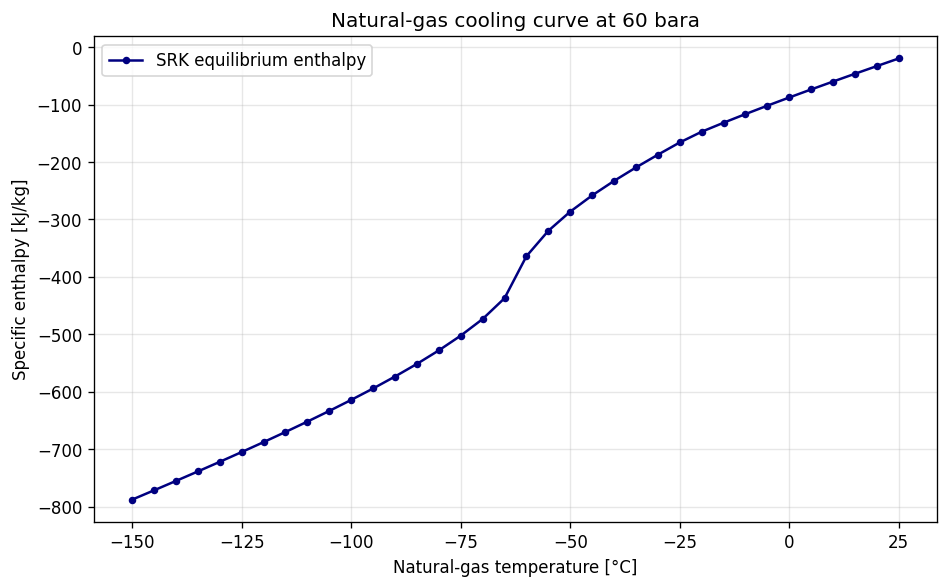

In [6]:
figure, enthalpy_axis = plt.subplots(figsize=(8.0, 5.0))

enthalpy_axis.plot(
    cooling_curve["temperature [°C]"],
    cooling_curve["enthalpy [kJ/kg]"],
    color="navy",
    marker="o",
    markersize=3.5,
    label="SRK equilibrium enthalpy",
)
enthalpy_axis.set_xlabel("Natural-gas temperature [°C]")
enthalpy_axis.set_ylabel("Specific enthalpy [kJ/kg]")
enthalpy_axis.set_title("Natural-gas cooling curve at 60 bara")
enthalpy_axis.grid(alpha=0.3)
enthalpy_axis.legend()
figure.tight_layout()
plt.show()


## 6. A staged NeqSim liquefaction train

Four named cooler blocks make intermediate checks visible: precooling to -35 °C, warm
liquefaction to -80 °C, cold liquefaction to -120 °C, and subcooling to -145 °C. They represent
temperature intervals in a multi-stream exchanger; they are not four independent utility
coolers.

`ProcessSystem.run()` executes the feed and each cooler in order. Each outlet stream carries a
new thermodynamic state, so downstream units receive consistent composition, flow, pressure,
and enthalpy.


In [7]:
feed_stream = Stream(
    "pretreated natural gas",
    make_srk_fluid(
        FEED_TEMPERATURE_C,
        FEED_PRESSURE_BARA,
        BASE_COMPOSITION,
    ),
)
feed_stream.setFlowRate(FEED_FLOW_KG_PER_H, "kg/hr")
feed_stream.setTemperature(FEED_TEMPERATURE_C, "C")
feed_stream.setPressure(FEED_PRESSURE_BARA, "bara")

cooling_targets_c = [-35.0, -80.0, -120.0, PRE_FLASH_TEMPERATURE_C]
cooler_names = ["precooler", "warm liquefier", "cold liquefier", "subcooler"]
liquefaction_process = ProcessSystem()
liquefaction_process.add(feed_stream)
liquefaction_coolers = []
upstream_stream = feed_stream

for cooler_name, target_temperature_c in zip(cooler_names, cooling_targets_c):
    cooler = Cooler(cooler_name, upstream_stream)
    cooler.setOutTemperature(target_temperature_c + 273.15)
    liquefaction_process.add(cooler)
    liquefaction_coolers.append(cooler)
    upstream_stream = cooler.getOutletStream()

liquefaction_process.run()

stage_results = pd.DataFrame(
    {
        "stage": cooler_names,
        "outlet temperature [°C]": [
            cooler.getOutletStream().getTemperature("C")
            for cooler in liquefaction_coolers
        ],
        "removed duty [MW]": [
            abs(cooler.getDuty()) / 1.0e6
            for cooler in liquefaction_coolers
        ],
    }
)

print(stage_results.to_string(index=False))


         stage  outlet temperature [°C]  removed duty [MW]
     precooler                    -35.0           5.273806
warm liquefier                    -80.0           8.849579
cold liquefier                   -120.0           4.436530
     subcooler                   -145.0           2.331365


## 7. Independent cooler-duty verification

The sum of the unit duties should equal the overall feed-to-subcooled-stream enthalpy change.
This check tests the flowsheet wiring, unit conversion, and sign handling independently of the
individual duty reports.

The specific refrigeration requirement is reported per kilogram of feed. The later flash-gas
loss means the value per kilogram of saleable LNG is higher.


In [8]:
subcooled_stream = liquefaction_coolers[-1].getOutletStream()
feed_mass_rate_kg_per_s = feed_stream.getFlowRate("kg/sec")
subcooled_enthalpy_j_per_kg = subcooled_stream.getFluid().getEnthalpy("J/kg")
overall_removed_duty_w = feed_mass_rate_kg_per_s * (
    feed_enthalpy_j_per_kg - subcooled_enthalpy_j_per_kg
)
summed_cooler_duty_w = sum(
    abs(cooler.getDuty())
    for cooler in liquefaction_coolers
)
duty_relative_error = abs(summed_cooler_duty_w - overall_removed_duty_w) / (
    overall_removed_duty_w
)
specific_refrigeration_kwh_per_kg_feed = (
    overall_removed_duty_w / feed_mass_rate_kg_per_s / 3.6e6
)

assert duty_relative_error < 1.0e-9

print(f"Overall removed duty [MW]: {overall_removed_duty_w / 1.0e6:.6f}")
print(f"Sum of cooler duties [MW]: {summed_cooler_duty_w / 1.0e6:.6f}")
print(f"Duty relative closure [-]: {duty_relative_error:.3e}")
print(
    "Specific refrigeration [kWh(th)/kg feed]: "
    f"{specific_refrigeration_kwh_per_kg_feed:.6f}"
)


Overall removed duty [MW]: 20.891281
Sum of cooler duties [MW]: 20.891281
Duty relative closure [-]: 0.000e+00
Specific refrigeration [kWh(th)/kg feed]: 0.208913


## 8. Joule--Thomson letdown and flash separation

The product valve is treated as steady, adiabatic, and without shaft work. Its governing
relation is therefore approximately isenthalpic:

$$
h_{\mathrm{in}} = h_{\mathrm{out}}
$$

At 1.2 bara, part of the stream flashes. The separator performs equilibrium phase routing but
does not add heat or pressure loss. The flash-gas fraction is a consequence of EOS enthalpy and
phase equilibrium, not an assigned recovery factor.


In [9]:
product_valve = ThrottlingValve("LNG product valve", subcooled_stream)
product_valve.setOutletPressure(PRODUCT_PRESSURE_BARA)

flash_separator = Separator("LNG flash drum", product_valve.getOutletStream())
product_process = ProcessSystem()
product_process.add(product_valve)
product_process.add(flash_separator)
product_process.run()

valve_outlet = product_valve.getOutletStream()
lng_stream = flash_separator.getLiquidOutStream()
flash_gas_stream = flash_separator.getGasOutStream()

inlet_mass_kg_per_h = subcooled_stream.getFlowRate("kg/hr")
lng_mass_kg_per_h = lng_stream.getFlowRate("kg/hr")
flash_gas_mass_kg_per_h = flash_gas_stream.getFlowRate("kg/hr")
lng_mass_yield = lng_mass_kg_per_h / inlet_mass_kg_per_h

print(f"Valve outlet temperature [°C]: {valve_outlet.getTemperature('C'):.4f}")
print(f"LNG mass flow [kg/h]: {lng_mass_kg_per_h:.3f}")
print(f"Flash-gas mass flow [kg/h]: {flash_gas_mass_kg_per_h:.3f}")
print(f"LNG mass yield [kg/kg feed]: {lng_mass_yield:.6f}")


Valve outlet temperature [°C]: -158.5862
LNG mass flow [kg/h]: 88922.668
Flash-gas mass flow [kg/h]: 11077.332
LNG mass yield [kg/kg feed]: 0.889227


## 9. Product balance and component partitioning

Total mass must close around the flash drum:

$$
\dot m_{\mathrm{feed}} = \dot m_{\mathrm{LNG}} + \dot m_{\mathrm{flash\ gas}}
$$

The vapor should be enriched in nitrogen and methane, while ethane and heavier hydrocarbons
prefer the liquid. This qualitative limiting-case check is useful because a numerically closed
total balance alone cannot detect swapped outlet connections.


In [10]:
separator_mass_error_kg_per_h = abs(
    inlet_mass_kg_per_h - lng_mass_kg_per_h - flash_gas_mass_kg_per_h
)
valve_inlet_enthalpy_j_per_kg = subcooled_stream.getFluid().getEnthalpy("J/kg")
valve_outlet_enthalpy_j_per_kg = valve_outlet.getFluid().getEnthalpy("J/kg")
valve_enthalpy_relative_error = abs(
    valve_inlet_enthalpy_j_per_kg - valve_outlet_enthalpy_j_per_kg
) / abs(valve_inlet_enthalpy_j_per_kg)

partition_records = []

for component_name in BASE_COMPOSITION:
    gas_mole_fraction = (
        flash_gas_stream.getFluid()
        .getPhase(0)
        .getComponent(component_name)
        .getx()
    )
    liquid_mole_fraction = (
        lng_stream.getFluid()
        .getPhase(0)
        .getComponent(component_name)
        .getx()
    )
    partition_records.append(
        {
            "component": component_name,
            "flash gas [mol/mol]": gas_mole_fraction,
            "LNG [mol/mol]": liquid_mole_fraction,
        }
    )

partition_table = pd.DataFrame(partition_records)

assert separator_mass_error_kg_per_h < 1.0e-6
assert valve_enthalpy_relative_error < 0.005
assert partition_table.loc[0, "flash gas [mol/mol]"] > partition_table.loc[0, "LNG [mol/mol]"]
assert partition_table.loc[2, "LNG [mol/mol]"] > partition_table.loc[2, "flash gas [mol/mol]"]

print(partition_table.to_string(index=False))
print(f"Separator mass error [kg/h]: {separator_mass_error_kg_per_h:.3e}")
print(f"Valve enthalpy relative error [-]: {valve_enthalpy_relative_error:.3e}")


component  flash gas [mol/mol]  LNG [mol/mol]
 nitrogen         6.636008e-02       0.002269
  methane         9.335096e-01       0.884032
   ethane         1.297617e-04       0.068213
  propane         5.222357e-07       0.028429
 i-butane         4.679942e-09       0.005686
 n-butane         2.244911e-09       0.011372
Separator mass error [kg/h]: 1.091e-11
Valve enthalpy relative error [-]: 1.310e-03


## 10. Feed-pressure sensitivity

Pressure changes both high-pressure enthalpy and the downstream equilibrium state. To isolate
that effect, the pre-flash temperature, product pressure, flow, and composition remain fixed.
Each scenario constructs fresh objects, preventing hidden state from one flash from contaminating
the next.

This is a sensitivity study, not a compressor optimization: upstream feed-compression power and
exchanger pressure drop are outside the boundary.


In [11]:
def simulate_flash_yield(pressure_bara, composition):
    scenario_fluid = make_srk_fluid(
        PRE_FLASH_TEMPERATURE_C,
        pressure_bara,
        composition,
    )
    scenario_feed = Stream(f"feed at {pressure_bara:.1f} bara", scenario_fluid)
    scenario_feed.setFlowRate(FEED_FLOW_KG_PER_H, "kg/hr")
    scenario_feed.setTemperature(PRE_FLASH_TEMPERATURE_C, "C")
    scenario_feed.setPressure(pressure_bara, "bara")

    scenario_valve = ThrottlingValve(
        f"valve from {pressure_bara:.1f} bara",
        scenario_feed,
    )
    scenario_valve.setOutletPressure(PRODUCT_PRESSURE_BARA)
    scenario_separator = Separator(
        f"separator for {pressure_bara:.1f} bara",
        scenario_valve.getOutletStream(),
    )
    scenario_process = ProcessSystem()
    scenario_process.add(scenario_feed)
    scenario_process.add(scenario_valve)
    scenario_process.add(scenario_separator)
    scenario_process.run()

    liquid_flow_kg_per_h = scenario_separator.getLiquidOutStream().getFlowRate("kg/hr")
    outlet_temperature_c = scenario_valve.getOutletStream().getTemperature("C")
    return liquid_flow_kg_per_h / FEED_FLOW_KG_PER_H, outlet_temperature_c


pressure_cases_bara = np.arange(30.0, 81.0, 10.0)
pressure_results = []

for pressure_bara in pressure_cases_bara:
    yield_value, outlet_temperature_c = simulate_flash_yield(
        float(pressure_bara),
        BASE_COMPOSITION,
    )
    pressure_results.append(
        {
            "pre-flash pressure [bara]": pressure_bara,
            "LNG mass yield [kg/kg feed]": yield_value,
            "valve outlet temperature [°C]": outlet_temperature_c,
        }
    )

pressure_table = pd.DataFrame(pressure_results)

assert pressure_table["LNG mass yield [kg/kg feed]"].between(0.0, 1.0).all()
assert np.all(np.diff(pressure_table["LNG mass yield [kg/kg feed]"]) < 0.0)

print(pressure_table.to_string(index=False))


 pre-flash pressure [bara]  LNG mass yield [kg/kg feed]  valve outlet temperature [°C]
                      30.0                     0.895671                    -158.639467
                      40.0                     0.893570                    -158.621682
                      50.0                     0.891425                    -158.603961
                      60.0                     0.889227                    -158.586218
                      70.0                     0.886990                    -158.568599
                      80.0                     0.884711                    -158.551059


## 11. Reading the pressure result

For this fixed -145 °C inlet state, SRK predicts a small decrease in LNG yield as pressure rises
from 30 to 80 bara. This direction is not a universal design rule: changing pressure also changes
the upstream cooling curve, compression work, exchanger pinch, and feasible subcooling.

The important workflow lesson is to vary one boundary condition at a time and rebuild the full
thermodynamic state for every scenario.


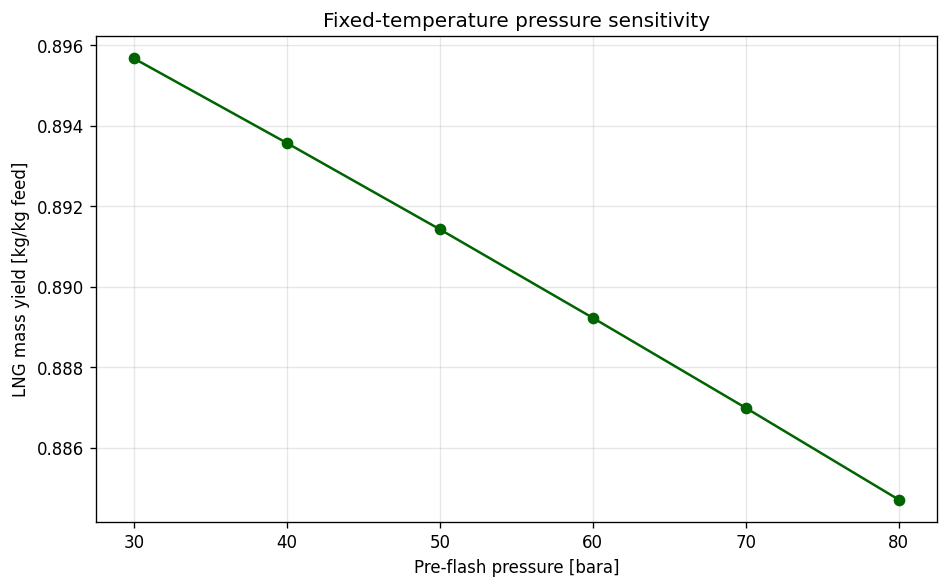

In [12]:
pressure_figure, pressure_axis = plt.subplots(figsize=(8.0, 5.0))

pressure_axis.plot(
    pressure_table["pre-flash pressure [bara]"],
    pressure_table["LNG mass yield [kg/kg feed]"],
    color="darkgreen",
    marker="o",
)
pressure_axis.set_xlabel("Pre-flash pressure [bara]")
pressure_axis.set_ylabel("LNG mass yield [kg/kg feed]")
pressure_axis.set_title("Fixed-temperature pressure sensitivity")
pressure_axis.grid(alpha=0.3)
pressure_figure.tight_layout()
plt.show()


## 12. Feed-richness sensitivity

Ethane and propane are less volatile than methane. A richness multiplier scales their base mole
fractions while methane closes the composition to one; nitrogen and butanes remain fixed. At the
same pressure and pre-flash temperature, a richer feed should send a larger fraction of mass to
the liquid product.

This controlled exercise is not a feed assay. Real composition changes are correlated and must
also be checked for heavy-hydrocarbon freezing and product heating-value limits.


In [13]:
richness_multipliers = np.array([0.5, 1.0, 1.5, 2.0])
richness_results = []

for richness_multiplier in richness_multipliers:
    ethane_fraction = BASE_COMPOSITION["ethane"] * richness_multiplier
    propane_fraction = BASE_COMPOSITION["propane"] * richness_multiplier
    fixed_fraction = (
        BASE_COMPOSITION["nitrogen"]
        + BASE_COMPOSITION["i-butane"]
        + BASE_COMPOSITION["n-butane"]
    )
    methane_fraction = 1.0 - ethane_fraction - propane_fraction - fixed_fraction
    scenario_composition = {
        "nitrogen": BASE_COMPOSITION["nitrogen"],
        "methane": methane_fraction,
        "ethane": ethane_fraction,
        "propane": propane_fraction,
        "i-butane": BASE_COMPOSITION["i-butane"],
        "n-butane": BASE_COMPOSITION["n-butane"],
    }
    yield_value, outlet_temperature_c = simulate_flash_yield(
        FEED_PRESSURE_BARA,
        scenario_composition,
    )
    richness_results.append(
        {
            "C2/C3 richness multiplier [-]": richness_multiplier,
            "methane [mol/mol]": methane_fraction,
            "LNG mass yield [kg/kg feed]": yield_value,
            "valve outlet temperature [°C]": outlet_temperature_c,
        }
    )

richness_table = pd.DataFrame(richness_results)

assert np.all(np.diff(richness_table["LNG mass yield [kg/kg feed]"]) > 0.0)

print(richness_table.to_string(index=False))


 C2/C3 richness multiplier [-]  methane [mol/mol]  LNG mass yield [kg/kg feed]  valve outlet temperature [°C]
                           0.5             0.9325                     0.883769                    -159.123397
                           1.0             0.8900                     0.889231                    -158.586251
                           1.5             0.8475                     0.893671                    -158.041218
                           2.0             0.8050                     0.897541                    -157.475739


## 13. Propane precooling as a state-point model

Baseload C3MR plants use propane evaporation for warm-end precooling and a mixed refrigerant for
liquefaction and subcooling. Here, one kilogram per second of propane is condensed at 15 bara and
35 °C, throttled to 1.5 bara, evaporated to -25 °C, compressed, and recondenser-cooled.

The evaporator duty is a **specific state-point screening value** in kJ/kg propane. It does not
size a complete multilevel propane loop, condenser, or exchanger. Compressor efficiency is an
explicit educational assumption of 0.78.


In [14]:
propane_fluid = make_srk_fluid(35.0, 15.0, {"propane": 1.0})
propane_feed = Stream("high-pressure propane", propane_fluid)
propane_feed.setFlowRate(3_600.0, "kg/hr")
propane_feed.setTemperature(35.0, "C")
propane_feed.setPressure(15.0, "bara")

propane_valve = ThrottlingValve("propane valve", propane_feed)
propane_valve.setOutletPressure(1.5)
propane_evaporator = Heater("propane evaporator", propane_valve.getOutletStream())
propane_evaporator.setOutTemperature(-25.0 + 273.15)
propane_compressor = Compressor(
    "propane compressor",
    propane_evaporator.getOutletStream(),
)
propane_compressor.setOutletPressure(15.0)
propane_compressor.setIsentropicEfficiency(0.78)
propane_condenser = Cooler(
    "propane condenser",
    propane_compressor.getOutletStream(),
)
propane_condenser.setOutTemperature(35.0 + 273.15)

propane_process = ProcessSystem()

for unit in [
    propane_feed,
    propane_valve,
    propane_evaporator,
    propane_compressor,
    propane_condenser,
]:
    propane_process.add(unit)

propane_process.run()

propane_refrigeration_kj_per_kg = propane_evaporator.getDuty() / 1_000.0
propane_compressor_work_kj_per_kg = propane_compressor.getPower("kW")

assert propane_refrigeration_kj_per_kg > 0.0
assert propane_compressor_work_kj_per_kg > 0.0

propane_valve_temperature_c = propane_valve.getOutletStream().getTemperature("C")

print(f"Propane valve outlet temperature [°C]: {propane_valve_temperature_c:.3f}")
print(f"Propane refrigeration [kJ/kg]: {propane_refrigeration_kj_per_kg:.3f}")
print(f"Propane compressor work [kJ/kg]: {propane_compressor_work_kj_per_kg:.3f}")


Propane valve outlet temperature [°C]: -32.655
Propane refrigeration [kJ/kg]: 255.713
Propane compressor work [kJ/kg]: 145.571


## 14. Mixed-refrigerant composition screening

A single mixed refrigerant distributes boiling temperatures across the natural-gas cooling
curve. The simple loop below compresses from 4 to 45 bara in two stages, intercools, precools the
high-pressure fluid to -35 °C, throttles it, and warms it to 25 °C.

Methane is varied while nitrogen stays at 0.05 mol/mol and the balance is shared by ethane and
propane. The cold-end temperatures are not low enough to represent a complete LNG exchanger;
the calculation intentionally screens **state-point tradeoffs**, not plant specific power.


In [15]:
def screen_mixed_refrigerant(methane_fraction):
    nitrogen_fraction = 0.05
    ethane_fraction = 0.35
    propane_fraction = 1.0 - nitrogen_fraction - methane_fraction - ethane_fraction
    refrigerant_composition = {
        "nitrogen": nitrogen_fraction,
        "methane": methane_fraction,
        "ethane": ethane_fraction,
        "propane": propane_fraction,
    }
    refrigerant_fluid = make_srk_fluid(25.0, 4.0, refrigerant_composition)
    refrigerant_feed = Stream(
        f"MR suction {methane_fraction:.2f}",
        refrigerant_fluid,
    )
    refrigerant_feed.setFlowRate(3_600.0, "kg/hr")
    refrigerant_feed.setTemperature(25.0, "C")
    refrigerant_feed.setPressure(4.0, "bara")

    first_compressor = Compressor("MR first compressor", refrigerant_feed)
    first_compressor.setOutletPressure(15.0)
    first_compressor.setIsentropicEfficiency(0.78)
    intercooler = Cooler("MR intercooler", first_compressor.getOutletStream())
    intercooler.setOutTemperature(30.0 + 273.15)
    second_compressor = Compressor("MR second compressor", intercooler.getOutletStream())
    second_compressor.setOutletPressure(45.0)
    second_compressor.setIsentropicEfficiency(0.78)
    precooler = Cooler("MR precooler", second_compressor.getOutletStream())
    precooler.setOutTemperature(-35.0 + 273.15)
    refrigerant_valve = ThrottlingValve("MR valve", precooler.getOutletStream())
    refrigerant_valve.setOutletPressure(4.0)
    refrigerant_warmer = Heater("MR warmer", refrigerant_valve.getOutletStream())
    refrigerant_warmer.setOutTemperature(25.0 + 273.15)

    refrigerant_process = ProcessSystem()

    for unit in [
        refrigerant_feed,
        first_compressor,
        intercooler,
        second_compressor,
        precooler,
        refrigerant_valve,
        refrigerant_warmer,
    ]:
        refrigerant_process.add(unit)

    refrigerant_process.run()
    compression_work_kw = (
        first_compressor.getPower("kW") + second_compressor.getPower("kW")
    )
    return {
        "methane in MR [mol/mol]": methane_fraction,
        "JT outlet temperature [°C]": refrigerant_valve.getOutletStream().getTemperature("C"),
        "available refrigeration [kJ/kg MR]": refrigerant_warmer.getDuty() / 1_000.0,
        "compression work [kJ/kg MR]": compression_work_kw,
    }


mixed_refrigerant_table = pd.DataFrame(
    [
        screen_mixed_refrigerant(methane_fraction)
        for methane_fraction in [0.35, 0.40, 0.45, 0.50]
    ]
)

assert np.all(np.diff(mixed_refrigerant_table["JT outlet temperature [°C]"]) < 0.0)
assert (mixed_refrigerant_table["available refrigeration [kJ/kg MR]"] > 0.0).all()

print(mixed_refrigerant_table.to_string(index=False))


 methane in MR [mol/mol]  JT outlet temperature [°C]  available refrigeration [kJ/kg MR]  compression work [kJ/kg MR]
                    0.35                  -75.628997                          452.205093                   280.781347
                    0.40                  -79.585423                          443.567287                   298.993882
                    0.45                  -81.735375                          420.441348                   319.096739
                    0.50                  -83.925503                          392.560813                   341.445856


## 15. Nitrogen-expander state-point model

An nitrogen-expander process uses a noncondensing, inert refrigerant. This example compresses
nitrogen from 5 to 120 bara in two stages, precools the high-pressure gas to -40 °C, and expands
it back to 5 bara with 0.85 isentropic efficiency. The expander produces shaft work and a cold
stream that can warm against the natural-gas cooling curve.

Net input power is compressor power minus recovered expander power:

$$
\dot W_{\mathrm{net}} = \dot W_{\mathrm{compressors}} - |\dot W_{\mathrm{expander}}|
$$

All powers are in kW. The extreme pressure ratio is for educational state-point screening and
must not be read as an equipment recommendation.


In [16]:
nitrogen_fluid = make_srk_fluid(25.0, 5.0, {"nitrogen": 1.0})
nitrogen_feed = Stream("nitrogen suction", nitrogen_fluid)
nitrogen_feed.setFlowRate(3_600.0, "kg/hr")
nitrogen_feed.setTemperature(25.0, "C")
nitrogen_feed.setPressure(5.0, "bara")

nitrogen_compressor_1 = Compressor("nitrogen compressor 1", nitrogen_feed)
nitrogen_compressor_1.setOutletPressure(25.0)
nitrogen_compressor_1.setIsentropicEfficiency(0.82)
nitrogen_intercooler = Cooler(
    "nitrogen intercooler",
    nitrogen_compressor_1.getOutletStream(),
)
nitrogen_intercooler.setOutTemperature(30.0 + 273.15)
nitrogen_compressor_2 = Compressor(
    "nitrogen compressor 2",
    nitrogen_intercooler.getOutletStream(),
)
nitrogen_compressor_2.setOutletPressure(120.0)
nitrogen_compressor_2.setIsentropicEfficiency(0.82)
nitrogen_precooler = Cooler(
    "nitrogen precooler",
    nitrogen_compressor_2.getOutletStream(),
)
nitrogen_precooler.setOutTemperature(-40.0 + 273.15)
nitrogen_expander = Expander(
    "nitrogen expander",
    nitrogen_precooler.getOutletStream(),
)
nitrogen_expander.setOutletPressure(5.0)
nitrogen_expander.setIsentropicEfficiency(0.85)
nitrogen_warmer = Heater("nitrogen warmer", nitrogen_expander.getOutletStream())
nitrogen_warmer.setOutTemperature(25.0 + 273.15)

nitrogen_process = ProcessSystem()

for unit in [
    nitrogen_feed,
    nitrogen_compressor_1,
    nitrogen_intercooler,
    nitrogen_compressor_2,
    nitrogen_precooler,
    nitrogen_expander,
    nitrogen_warmer,
]:
    nitrogen_process.add(unit)

nitrogen_process.run()

nitrogen_compressor_power_kw = (
    nitrogen_compressor_1.getPower("kW") + nitrogen_compressor_2.getPower("kW")
)
nitrogen_expander_power_kw = abs(nitrogen_expander.getPower("kW"))
nitrogen_net_power_kw = nitrogen_compressor_power_kw - nitrogen_expander_power_kw
nitrogen_refrigeration_kj_per_kg = nitrogen_warmer.getDuty() / 1_000.0

assert nitrogen_expander.getOutletStream().getTemperature("C") < PRE_FLASH_TEMPERATURE_C
assert nitrogen_net_power_kw > 0.0
assert nitrogen_refrigeration_kj_per_kg > 0.0

nitrogen_expander_temperature_c = nitrogen_expander.getOutletStream().getTemperature("C")

print(f"Nitrogen expander outlet [°C]: {nitrogen_expander_temperature_c:.3f}")
print(f"Nitrogen refrigeration [kJ/kg]: {nitrogen_refrigeration_kj_per_kg:.3f}")
print(f"Nitrogen compressor power [kW]: {nitrogen_compressor_power_kw:.3f}")
print(f"Nitrogen expander recovery [kW]: {nitrogen_expander_power_kw:.3f}")
print(f"Nitrogen net input [kW]: {nitrogen_net_power_kw:.3f}")


Nitrogen expander outlet [°C]: -170.236
Nitrogen refrigeration [kJ/kg]: 209.541
Nitrogen compressor power [kW]: 445.000
Nitrogen expander recovery [kW]: 103.379
Nitrogen net input [kW]: 341.621


## 16. Architecture comparison: what is comparable

The next table compares only rigorously defined **one-kilogram-per-second state points**. Propane
is effective at the warm end, mixed refrigerant spans a broader boiling range, and expanded
nitrogen reaches the coldest state here. Their refrigeration and work values are not a ranking of
commercial processes because the boundaries differ and the loops omit exchanger integration,
recirculation convergence, pressure losses, and mechanical efficiencies.

A defensible plant comparison would hold feed, product, ambient sink, exchanger minimum approach,
pressure losses, driver efficiencies, and availability constant, then solve every recycle.


In [17]:
architecture_table = pd.DataFrame(
    [
        {
            "screening architecture": "propane precooling",
            "cold state [°C]": propane_valve.getOutletStream().getTemperature("C"),
            "refrigeration [kJ/kg refrigerant]": propane_refrigeration_kj_per_kg,
            "net shaft input [kJ/kg refrigerant]": propane_compressor_work_kj_per_kg,
        },
        {
            "screening architecture": "mixed refrigerant",
            "cold state [°C]": mixed_refrigerant_table.loc[
                2,
                "JT outlet temperature [°C]",
            ],
            "refrigeration [kJ/kg refrigerant]": mixed_refrigerant_table.loc[
                2,
                "available refrigeration [kJ/kg MR]",
            ],
            "net shaft input [kJ/kg refrigerant]": mixed_refrigerant_table.loc[
                2,
                "compression work [kJ/kg MR]",
            ],
        },
        {
            "screening architecture": "nitrogen expander",
            "cold state [°C]": nitrogen_expander.getOutletStream().getTemperature("C"),
            "refrigeration [kJ/kg refrigerant]": nitrogen_refrigeration_kj_per_kg,
            "net shaft input [kJ/kg refrigerant]": nitrogen_net_power_kw,
        },
    ]
)

assert np.isfinite(architecture_table.select_dtypes(include="number")).all().all()

print(architecture_table.to_string(index=False))


screening architecture  cold state [°C]  refrigeration [kJ/kg refrigerant]  net shaft input [kJ/kg refrigerant]
    propane precooling       -32.654980                         255.713384                           145.570733
     mixed refrigerant       -81.735375                         420.441348                           319.096739
     nitrogen expander      -170.235601                         209.540512                           341.620866


## 17. Practical limitations and troubleshooting

**Validity limits.** Results apply to the stated synthetic, pretreated fluid and equilibrium SRK
model. The notebook omits pretreatment, NGL removal, multi-stream exchanger pinch analysis,
recycle convergence, refrigerant inventory, pressure drop, rotating-equipment maps, heat leak,
startup, dynamic control, metallurgy, and relief design. It is an educational screening model,
not a FEED or equipment guarantee.

**Troubleshooting.** If a flash fails, check that temperature is in kelvin when a Java method
expects an absolute value, pressure is positive, mole fractions sum to one, and the component
names exist. If a separator outlet is nearly zero, inspect phase count before reading phase
properties. If duties have an unexpected sign, document the unit convention and verify with an
independent enthalpy-rate balance. Always create fresh scenario objects in sensitivity loops.


In [18]:
verification_checks = {
    "composition closes": np.isclose(composition_sum, 1.0, atol=1.0e-12),
    "feed is single phase": feed_fluid.getNumberOfPhases() == 1,
    "cooling enthalpy decreases": bool(np.all(enthalpy_steps < 0.0)),
    "cooling curve enters two-phase region": (
        cooling_curve["equilibrium phase count [-]"].max() >= 2
    ),
    "cooler duty closes": duty_relative_error < 1.0e-9,
    "separator mass closes": separator_mass_error_kg_per_h < 1.0e-6,
    "valve is approximately isenthalpic": valve_enthalpy_relative_error < 0.005,
    "LNG yield is physical": 0.0 < lng_mass_yield < 1.0,
    "pressure study is bounded": (
        pressure_table["LNG mass yield [kg/kg feed]"].between(0.0, 1.0).all()
    ),
    "richer feed raises yield": bool(
        np.all(np.diff(richness_table["LNG mass yield [kg/kg feed]"]) > 0.0)
    ),
    "propane refrigeration is positive": propane_refrigeration_kj_per_kg > 0.0,
    "MR refrigeration is positive": (
        mixed_refrigerant_table["available refrigeration [kJ/kg MR]"] > 0.0
    ).all(),
    "nitrogen reaches cold end": (
        nitrogen_expander.getOutletStream().getTemperature("C")
        < PRE_FLASH_TEMPERATURE_C
    ),
    "nitrogen net work is positive": nitrogen_net_power_kw > 0.0,
}

failed_checks = [
    check_name
    for check_name, passed in verification_checks.items()
    if not passed
]

assert not failed_checks, failed_checks

print(f"Engineering checks passed [-]: {len(verification_checks)}")

for check_name in verification_checks:
    print(f"PASS - {check_name}")


Engineering checks passed [-]: 14
PASS - composition closes
PASS - feed is single phase
PASS - cooling enthalpy decreases
PASS - cooling curve enters two-phase region
PASS - cooler duty closes
PASS - separator mass closes
PASS - valve is approximately isenthalpic
PASS - LNG yield is physical
PASS - pressure study is bounded
PASS - richer feed raises yield
PASS - propane refrigeration is positive
PASS - MR refrigeration is positive
PASS - nitrogen reaches cold end
PASS - nitrogen net work is positive


## 18. Summary, further exercises, and references

The SRK model predicts 20.891 MW of heat removal for the 100,000 kg/h base feed from 25 to
-145 °C. After isenthalpic letdown to 1.2 bara, the equilibrium separator produces about 88.9%
LNG by mass and a nitrogen/methane-rich flash gas. Independent mass and energy checks verify the
process connections. Pressure and richness studies show how to rebuild scenarios without hidden
state, while propane, mixed-refrigerant, and nitrogen models illustrate distinct refrigeration
state points without pretending to be complete plant cycles.

**Further exercises.** (1) Add exchanger pressure drops and recompute duty and yield. (2) Replace
SRK with Peng--Robinson and quantify model spread. (3) Develop hot and cold composite curves with
a stated minimum approach temperature. (4) Add a recycle and convergence strategy for one
refrigerant loop. (5) Introduce trace CO2 or water only after choosing an association-capable
model and a freeze-out validation method.

**Authoritative references.** NeqSim [thermodynamic models](https://equinor.github.io/neqsim/thermo/thermodynamic_models.html),
[thermodynamics recipes](https://equinor.github.io/neqsim/cookbook/thermodynamics-recipes.html),
and [process simulation guide](https://equinor.github.io/neqsim/process/process_simulation.html);
the current [NeqSim PyPI release](https://pypi.org/project/neqsim/); ISO 16903,
*Petroleum and natural gas industries — Characteristics of LNG, influencing the design, and
material selection*; and Mokhatab et al., *Handbook of Liquefied Natural Gas* (Elsevier, 2014).


In [19]:
machine_readable_results = {
    "neqsim_version": NEQSIM_VERSION,
    "feed_flow_kg_per_h": FEED_FLOW_KG_PER_H,
    "feed_pressure_bara": FEED_PRESSURE_BARA,
    "pre_flash_temperature_c": PRE_FLASH_TEMPERATURE_C,
    "product_pressure_bara": PRODUCT_PRESSURE_BARA,
    "removed_duty_mw": overall_removed_duty_w / 1.0e6,
    "lng_mass_flow_kg_per_h": lng_mass_kg_per_h,
    "flash_gas_mass_flow_kg_per_h": flash_gas_mass_kg_per_h,
    "lng_mass_yield_kg_per_kg_feed": lng_mass_yield,
    "checks_passed": len(verification_checks),
}

results_json = json.dumps(machine_readable_results, indent=2, sort_keys=True)
print(results_json)


{
  "checks_passed": 14,
  "feed_flow_kg_per_h": 100000.0,
  "feed_pressure_bara": 60.0,
  "flash_gas_mass_flow_kg_per_h": 11077.33234493955,
  "lng_mass_flow_kg_per_h": 88922.66765506043,
  "lng_mass_yield_kg_per_kg_feed": 0.8892266765506046,
  "neqsim_version": "3.16.0",
  "pre_flash_temperature_c": -145.0,
  "product_pressure_bara": 1.2,
  "removed_duty_mw": 20.891280584689966
}
